# Smart Sales and Customer Analysis Dashboard

In [19]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# Load Dataset

In [20]:
df = pd.read_csv("enterprise_sales_customer_analytics_large.csv")
df.head()


,Order ID,Customer ID,Customer Name,Segment,Order Date,Ship Date,Ship Mode,Region,State,Category,Product,Quantity,Unit Price,Discount (%),Sales,Profit,Payment Mode,Sales Person
0,1,CUST1053,Customer_82,Consumer,18-04-2022,21-04-2022,Express,North,Punjab,Furniture,Chair,1,1652,10.0,1486.8,226.35,Cash,SalesPerson_22
1,2,CUST1104,Customer_464,Consumer,18-05-2023,20-05-2023,Standard,North,Punjab,Electronics,Headphones,2,127,10.0,228.6,61.63,Debit Card,SalesPerson_9
2,3,CUST1820,Customer_248,Consumer,13-02-2022,16-02-2022,Same Day,West,Rajasthan,Furniture,Sofa,8,250,10.0,1800.0,275.47,Cash,SalesPerson_37
3,4,CUST1429,Customer_192,Home Office,08-10-2023,09-10-2023,Standard,West,Rajasthan,Office Supplies,Binder,9,2714,15.0,20762.1,4280.79,Debit Card,SalesPerson_47
4,5,CUST1396,Customer_294,Corporate,19-06-2022,23-06-2022,Standard,East,West Bengal,Furniture,Sofa,9,1702,NaN,15318.0,4088.89,Debit Card,SalesPerson_38


# Basic Cleaning

In [23]:
#Convert Date
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [22]:
#Remove duplicates
df.drop_duplicates(inplace=True)

#Handle missing values
df.ffill(inplace=True)   # forward fill

#Remove negative sales
df = df[df['Sales'] > 0]

df.shape  # shows rows and columns after cleaning

(12000, 18)

# Feature Engineering


In [24]:
#Extract time feature
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['DayOfWeek'] = df['Order Date'].dt.day_name()

# Profit Margin
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100


# Sales Forecasting

In [25]:
# Aggregate monthly sales
monthly = df.groupby('Month')['Sales'].sum().reset_index()

print("📊 Monthly Sales Data:")
print(monthly)

# Prepare model
X = monthly[['Month']]
y = monthly['Sales']
# Train model
model = LinearRegression()
model.fit(X, y)
last_year = df['Year'].max()
last_month = df[df['Year'] == last_year]['Month'].max()

if last_month == 12:
    next_month_value = 1
else:
    next_month_value = last_month + 1

next_month_df = pd.DataFrame({'Month': [next_month_value]})

prediction = model.predict(next_month_df)[0]

print("\n🔮 Predicted Sales for Next Month:")
print(round(prediction, 2))

📊 Monthly Sales Data:
    Month       Sales
0       1  8195989.60
1       2  7384470.20
2       3  7631202.50
3       4  7405091.60
4       5  7564212.10
5       6  7215092.90
6       7  7985545.10
7       8  7790271.90
8       9  8193391.95
9      10  8058481.05
10     11  8307293.40
11     12  8036831.80

🔮 Predicted Sales for Next Month:
7526763.43


In [8]:
# Train model
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Customer Segmentation

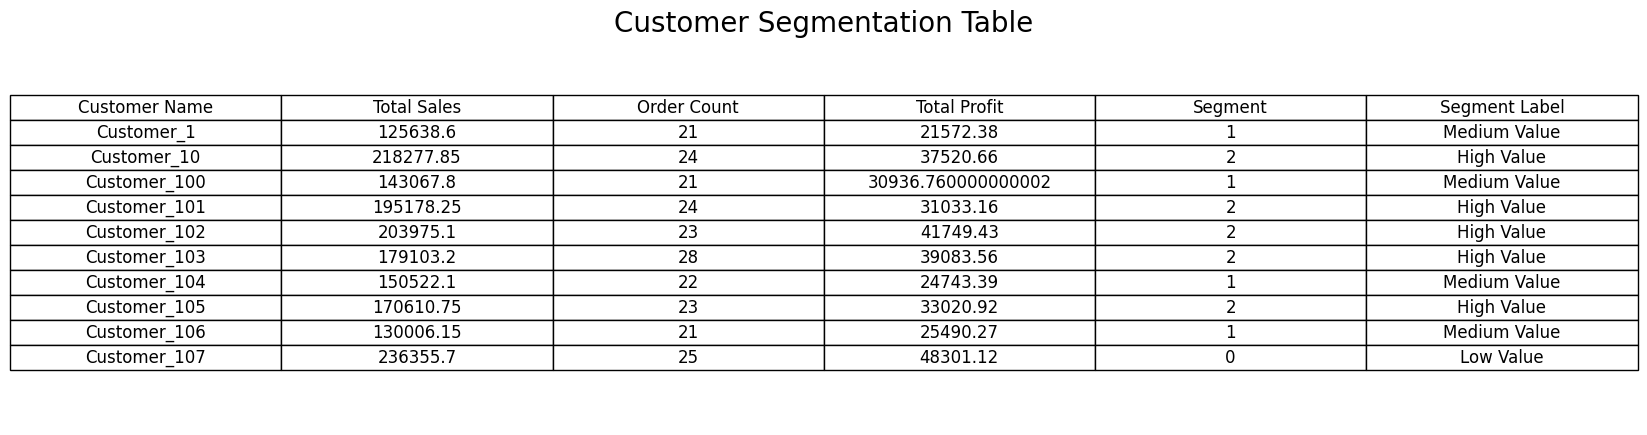

In [9]:
# Customer aggregation
customer = df.groupby('Customer Name').agg({
    'Sales': 'sum',
    'Order ID': 'count',
    'Profit': 'sum'
}).reset_index()

# Rename columns
customer.columns = ['Customer Name', 'Total Sales', 'Order Count', 'Total Profit']

# Scaling
features = ['Total Sales', 'Order Count', 'Total Profit']
scaler = StandardScaler()
scaled = scaler.fit_transform(customer[features])

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer['Segment'] = kmeans.fit_predict(scaled)

# Optional: Label segments for better understanding
segment_map = {
    0: 'Low Value',
    1: 'Medium Value',
    2: 'High Value'
}
customer['Segment Label'] = customer['Segment'].map(segment_map)

# Display table
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.axis('off')

table = plt.table(
    cellText=customer.head(10).values,
    colLabels=customer.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 1.5)

plt.title("Customer Segmentation Table", fontsize=20)
plt.show()

# State-based Product Recommendation

In [10]:
# Find best product per State
best_products = (
    df.loc[df.groupby('State')['Sales'].idxmax(), ['State', 'Product']]
    .rename(columns={'Product': 'Recommended Product'})
    .reset_index(drop=True)
)

# Display unique state recommendations
best_products

,State,Recommended Product
0,Assam,Pen
1,Delhi,Notebook
2,Gujarat,Pen
3,Haryana,Desk
4,Karnataka,Laptop
5,Kerala,Printer Paper
6,Maharashtra,Pen
7,Odisha,Chair
8,Punjab,Printer Paper
9,Rajasthan,Headphones


# High saled  Product 

In [13]:
top_products = (
    df.groupby('Product')['Sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_products.head(5)

,Product,Sales
0,Binder,8345208.05
1,Headphones,8182728.50
2,Mobile,7985513.35
3,Laptop,7911407.65
4,Tablet,7896817.20


In [14]:
# Step 1: Aggregate product performance by State + Product
product_state = (
    df.groupby(['State', 'Product'])
    .agg({'Sales': 'sum', 'Profit': 'sum'})
    .reset_index()
)

# Step 2: Get top 5 products overall
top_products = (
    df.groupby('Product')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# Step 3: Filter only top products
top_data = product_state[product_state['Product'].isin(top_products)]

# Step 4: Get best state for each product
best_state = (
    top_data.loc[top_data.groupby('Product')['Sales'].idxmax()]
)

# Step 5: Print recommendation message
for _, row in best_state.iterrows():
    print(f"""
✅ Product: {row['Product']}
📍 State: {row['State']}
💰 Total Sales: {int(row['Sales'])}
📈 Profit: {int(row['Profit'])}

👉 Recommendation: Increase production of {row['Product']} in {row['State']} 
   as it is a high-performing product with strong sales and profit.
""")


✅ Product: Binder
📍 State: Punjab
💰 Total Sales: 861502
📈 Profit: 169530

👉 Recommendation: Increase production of Binder in Punjab 
   as it is a high-performing product with strong sales and profit.


✅ Product: Headphones
📍 State: Haryana
💰 Total Sales: 839607
📈 Profit: 171567

👉 Recommendation: Increase production of Headphones in Haryana 
   as it is a high-performing product with strong sales and profit.


✅ Product: Laptop
📍 State: Gujarat
💰 Total Sales: 801939
📈 Profit: 155015

👉 Recommendation: Increase production of Laptop in Gujarat 
   as it is a high-performing product with strong sales and profit.


✅ Product: Mobile
📍 State: Gujarat
💰 Total Sales: 805790
📈 Profit: 161810

👉 Recommendation: Increase production of Mobile in Gujarat 
   as it is a high-performing product with strong sales and profit.


✅ Product: Tablet
📍 State: Gujarat
💰 Total Sales: 810058
📈 Profit: 158352

👉 Recommendation: Increase production of Tablet in Gujarat 
   as it is a high-performing product 

In [15]:
df.to_csv("tableau_ready_data_advanced.csv", index=False)

print("\n✅ Final dataset exported successfully!")


✅ Final dataset exported successfully!


In [16]:
import os
os.getcwd()
# It show the folder where your CSV is saved.

'D:\\MINIIIIIIIIIIIIIIIIIIIIIIII'